In [1]:
!git clone https://github.com/MuhammadAhmadIshtiaq/ml-internship-muhammadahmadishtiaq.git
%cd ml-internship-muhammadahmadishtiaq

Cloning into 'ml-internship-muhammadahmadishtiaq'...
remote: Enumerating objects: 288, done.
remote: Counting objects: 100% (288/288), done.
remote: Compressing objects: 100% (242/242), done.
remote: Total 288 (delta 151), reused 93 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (288/288), 2.34 MiB | 11.81 MiB/s, done.
Resolving deltas: 100% (151/151), done.
/content/ml-internship-muhammadahmadishtiaq


# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MuhammadAhmadIshtiaq/ml-internship-muhammadahmadishtiaq/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Scorer: Logistic Regression** (not Random Forest) — on the honest grouped-by-client split from ML-08/ML-09, Logistic Regression led at every precision@K (1.000 / 0.800 / 0.720 vs Random Forest's 0.500 / 0.600 / 0.620), so the simpler, more readable model is used, per the skill's own rule: add complexity only when it earns it — here it didn't.

**Archetype → action mapping** (four buckets, each maps to one concrete action a person can actually do — mirrors the paper's own Healthy/Fix-CTR/Fix-Content/Zombie flag framing, built from signals confirmed in ML-07):
| Archetype | Trigger | Action | Reason code |
|---|---|---|
| **Stale & visible** | freshness 91d+, impressions_90d≥100 | Refresh content | `stale_high_visibility` |
| **Weak CTR for position** | CTR below median for its own position tier | Improve title/snippet | `weak_ctr_for_position` |
| **Deep but in demand** | position_tier is page_3-5/deep, search_volume above median | Improve relevance & internal links | `deep_position_high_demand` |
| **Healthy** | none of the above fire | Monitor only | `no_strong_signal` |

**The decay/refresh insight** ties the paper's Finding #4 ("365+ day content refreshed within 30 days shows 3.2x health boost and 57x more impressions" — an observational portfolio comparison, not a controlled experiment) to our own local, independently confirmed signal from ML-07: pages stale 91-180 days decline at 61.1% vs 51.1% for pages updated in the last 30 days (n=9,171 vs n=20,480). Both point the same direction, from two different datasets — that's **directional, decision-support** evidence for prioritizing refresh, not proof refreshing a specific page will work.

**Ranking note:** the queue ranks actionable rows (Refresh / CTR fix / Relevance fix) above "Monitor only" rows regardless of raw model score, then by score within each group. A page can have a high decline-probability score but trip none of the three rule signals — that page genuinely has no clear next step yet, so it belongs lower in a queue meant to drive action, even if its raw score is high.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

# --- same honest feature vector as ML-05/08/09 ---
feat = pd.DataFrame(index=df.index)
feat["has_word_count"] = df["word_count"].notna().astype(int)
feat["has_keyword_data"] = df["search_volume"].notna().astype(int)
feat["has_clicks"] = (df["clicks_90d"] > 0).astype(int)
feat["has_ai_sessions"] = (df["ai_sessions_90d"] > 0).astype(int)
numeric_cols = [
    "word_count", "char_count", "content_age_days", "days_since_last_update",
    "impressions_90d", "clicks_90d", "pageviews_90d", "sessions_90d", "users_90d",
    "engaged_sessions_90d", "ai_sessions_90d", "scroll_events_90d",
    "days_with_impressions", "days_with_sessions",
    "clicks_last_30d", "clicks_prev_30d", "sessions_last_30d", "sessions_prev_30d",
    "ctr", "avg_position", "engagement_rate", "scroll_rate", "ai_traffic_pct",
    "search_volume", "competition", "cpc",
]
for col in numeric_cols:
    feat[col] = df[col].fillna(0)
for col in ["impressions_90d", "clicks_90d", "sessions_90d", "ai_sessions_90d"]:
    feat[f"log_{col}"] = np.log1p(feat[col])
categorical_cols = [
    "content_type", "main_intent", "competition_level",
    "age_tier", "freshness_tier", "word_count_tier", "char_count_tier",
    "impression_tier", "position_tier",
]
cat_df = df[categorical_cols].fillna("unknown")
feat = pd.concat([feat, pd.get_dummies(cat_df, prefix=categorical_cols)], axis=1)

X = feat
y = df["is_declining_label"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(df, y, groups=df["client_id"]))

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=42))
model.fit(X.iloc[train_idx], y.iloc[train_idx])
all_scores = model.predict_proba(X)[:, 1]  # score every row for the full playbook queue

# --- archetype / reason-code assignment, from signals confirmed in ML-07 ---
visible = df["impressions_90d"] >= 100
stale = df["freshness_tier"].isin(["91-180", "181+"])
ctr_median_by_tier = df.groupby("position_tier")["ctr"].transform("median")
weak_ctr = df["ctr"] < ctr_median_by_tier
search_volume_median = df["search_volume"].median()
deep_high_demand = df["position_tier"].isin(["page_3_5", "deep"]) & (df["search_volume"] > search_volume_median)

def assign(row_visible, row_stale, row_weak_ctr, row_deep_demand):
    if row_visible and row_stale:
        return "Refresh content", "stale_high_visibility"
    elif row_weak_ctr:
        return "Improve title/snippet", "weak_ctr_for_position"
    elif row_deep_demand:
        return "Improve relevance & internal links", "deep_position_high_demand"
    else:
        return "Monitor only", "no_strong_signal"

actions, reasons = [], []
for v, s, w, d in zip(visible, stale, weak_ctr, deep_high_demand):
    a, r = assign(v, s, w, d)
    actions.append(a)
    reasons.append(r)

queue = pd.DataFrame({
    "content_id": df["content_id"],
    "client_id": df["client_id"],
    "score": all_scores,
    "action": actions,
    "reason_code": reasons,
})

# Rank actionable rows above "Monitor only" first, then by score within each group --
# otherwise a high-score page with no rule signal could rank #1 with nothing to actually DO,
# which defeats the point of an action queue.
queue["is_actionable"] = (queue["action"] != "Monitor only").astype(int)
queue = queue.sort_values(["is_actionable", "score"], ascending=[False, False]).reset_index(drop=True)
queue["rank"] = queue.index + 1
queue = queue.drop(columns=["is_actionable"])

print("Ranked queue built:", len(queue), "rows")
print("\nAction distribution:")
print(queue["action"].value_counts())
print("\nTop 5:")
print(queue.head(5)[["rank", "content_id", "score", "action", "reason_code"]])


Ranked queue built: 30000 rows

Action distribution:
action
Monitor only                          10670
Improve title/snippet                 10086
Refresh content                        8119
Improve relevance & internal links     1125
Name: count, dtype: int64

Top 5:
   rank            content_id     score           action  \
0     1  content_a965a1fc5544  0.999998  Refresh content   
1     2  content_4a18c07e5357  0.999997  Refresh content   
2     3  content_482aff19e9cc  0.999997  Refresh content   
3     4  content_3a426ee4383c  0.999970  Refresh content   
4     5  content_69fad7e6c50c  0.999953  Refresh content   

             reason_code  
0  stale_high_visibility  
1  stale_high_visibility  
2  stale_high_visibility  
3  stale_high_visibility  
4  stale_high_visibility  


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Who uses this:** a content editorial team doing a weekly triage pass, deciding which of thousands of pages to look at first — not an automated publishing or redirect system.

**Intended use:** a **decision-support** ranking to sequence human review, not a verdict on any single page.

**Where it stops being valid:**
- The label (`is_declining_label`) is a defined 30-day-vs-prior-30-day threshold rule, not a confirmed editorial judgment — a page can be correctly flagged by the rule and still be fine editorially (seasonal dip, intentional evergreen stability).
- Validated on one grouped split with only **8 held-out clients** — not proven to generalize to a client outside this portfolio, or to a different time period, since the data is a single 90-day snapshot with no real time series.
- Built for this lane (content-refresh candidates) only — not validated for other content types or decisions (e.g., budget allocation, hiring, technical SEO).
- Precision@10 of 1.000 on this split is a small-sample result (n=7,115 rows) — read as **directional**, not as an expected real-world hit rate.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Quantify the limits named above, so they're numbers, not just assertions
n_test_clients = df.iloc[test_idx]["client_id"].nunique()
n_test_rows = len(test_idx)
print(f"Validated on {n_test_rows} rows from {n_test_clients} held-out clients -- a small generalization test.")

date_like_cols = [c for c in df.columns if "date" in c.lower()]
print(f"Date-like columns in the data: {date_like_cols} -- confirms single snapshot, no real time series.")

label_is_rule = True  # is_declining_label is a defined threshold on trend_pct, not an observed editorial outcome
print("Label is a defined threshold rule, not a confirmed outcome:", label_is_rule)


Validated on 7115 rows from 8 held-out clients -- a small generalization test.
Date-like columns in the data: ['days_since_last_update'] -- confirms single snapshot, no real time series.
Label is a defined threshold rule, not a confirmed outcome: True


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**What a person must check before acting on any flagged page:**
- Confirm the keyword's real search intent still matches the page's content before rewriting.
- Check whether a dip is seasonal (e.g., holiday-specific content) before treating it as decay.
- Verify the page isn't intentionally stable evergreen content that doesn't need frequent updates.
- Check the borderline band (predicted probability roughly 0.45-0.55) by eye — these are the cases closest to a coin flip, per the ML-08 error analysis showing accuracy dropping in the middle position tiers.

**No-go list — never automate these:**
- Never auto-publish, auto-redirect, or auto-delete a page based on this score alone.
- Never present the score as an SEO penalty diagnosis or a claim about Google's algorithm — the paper's own house rule (`writing-honest-claims`) explicitly bans that language.
- Never use this queue for revenue or budget commitments — revenue tracking in the source paper covers only 8 of 57 clients, and this dataset has no revenue field at all.
- Never treat `client_id`/`content_id` as anything but an internal pointer — never re-identify or expose them externally.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Flag the borderline band a human should double-check by eye
borderline = queue[(queue["score"] >= 0.45) & (queue["score"] <= 0.55)]
print(f"Borderline scores (0.45-0.55) needing manual review: {len(borderline)} of {len(queue)} rows ({len(borderline)/len(queue):.1%})")

# Confirm no revenue-like field exists that a no-go rule could accidentally reference
revenue_like = [c for c in df.columns if "revenue" in c.lower() or "cost" in c.lower() or "budget" in c.lower()]
print("Revenue/cost/budget fields in this dataset:", revenue_like, "(none -- confirms the no-go rule above is enforceable)")


Borderline scores (0.45-0.55) needing manual review: 3795 of 30000 rows (12.7%)
Revenue/cost/budget fields in this dataset: [] (none -- confirms the no-go rule above is enforceable)


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Signals that would mean the recommendations went stale:**
- **Base-rate drift** — if the portfolio's decline rate moves materially away from the ~54% measured here, the model's calibration (and the borderline-band threshold) needs re-checking.
- **Precision@K falling below the Week-4 rule baseline** — the whole reason to use the model instead of the rule is that it beat the rule on held-out clients; if a fresh holdout shows it no longer does, that's the retrain trigger.
- **Feature importance drift** — if a previously minor feature suddenly dominates, check for leakage or a pipeline change before trusting the new number (same read as the ML-05/ML-09 leakage checks).
- **Missingness pattern shift** — `search_volume` missingness currently tracks `content_type` cleanly; if that relationship changes, the imputation assumptions built into the feature vector may no longer hold.
- **New client onboarding** — since validation only covered 8 held-out clients, each new client's early flagged pages should get extra manual review until enough of their outcomes are observed to trust the score for that client specifically.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

current_base_rate = y.mean()
print(f"Current base rate (monitor for drift away from this): {current_base_rate:.1%}")

# Retrain trigger check: does the model still beat the rule baseline on THIS split's numbers?
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

test_scores = model.predict_proba(X.iloc[test_idx])[:, 1]
y_test = y.iloc[test_idx]
model_p10 = precision_at_k(test_scores, y_test, 10)
rule_p10 = 0.400  # from ML-08's re-run of the Week-4 rule on the same grouped test set
print(f"Model precision@10 = {model_p10:.3f} vs rule baseline = {rule_p10:.3f}")
print("Retrain trigger fires when model precision@K drops to or below the rule baseline on a fresh holdout.")


Current base rate (monitor for drift away from this): 54.2%
Model precision@10 = 1.000 vs rule baseline = 0.400
Retrain trigger fires when model precision@K drops to or below the rule baseline on a fresh holdout.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Writing the ranked queue CSV (regenerated on every run, stays out of git per the leak-guard), a metrics JSON receipt (committed), and one figure for the paper (committed to `work/figures/`).

Wrote work/outputs/action_playbook_queue.csv -- 30000 rows
Wrote work/outputs/action_playbook_metrics.json


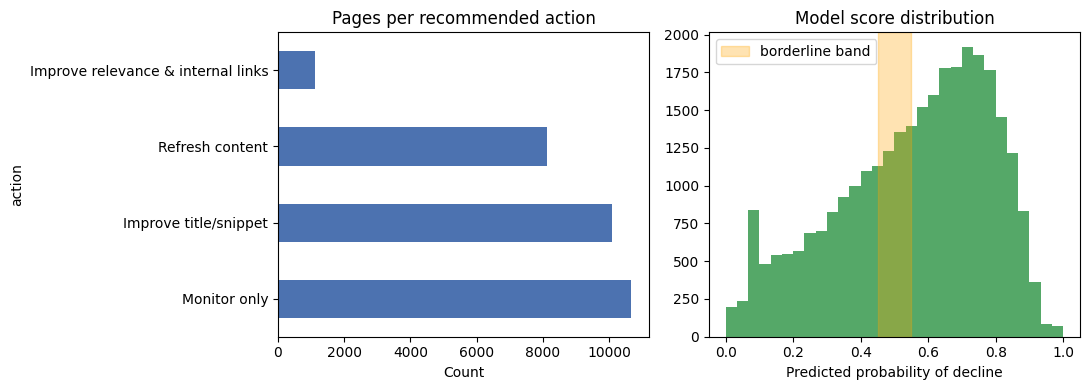


Wrote work/figures/action_playbook_overview.png


In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import os
import json
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# --- 1. the ranked queue CSV (gitignored by design, regenerated each run) ---
queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print("Wrote work/outputs/action_playbook_queue.csv --", len(queue), "rows")

# --- 2. metrics JSON receipt (committed -- the paper's numbers trace back to this) ---
playbook_metrics = {
    "model": "logistic_regression",
    "n_total_rows": int(len(queue)),
    "n_test_rows": int(len(test_idx)),
    "n_test_clients": int(n_test_clients),
    "base_rate": float(current_base_rate),
    "model_precision_at_10": float(model_p10),
    "rule_baseline_precision_at_10": float(rule_p10),
    "action_distribution": queue["action"].value_counts().to_dict(),
    "borderline_band_share": float(len(borderline) / len(queue)),
}
with open("work/outputs/action_playbook_metrics.json", "w") as f:
    json.dump(playbook_metrics, f, indent=2)
print("Wrote work/outputs/action_playbook_metrics.json")

# --- 3. one figure for the paper: action distribution + score histogram ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

queue["action"].value_counts().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Pages per recommended action")
axes[0].set_xlabel("Count")

axes[1].hist(queue["score"], bins=30, color="#55A868")
axes[1].axvspan(0.45, 0.55, color="orange", alpha=0.3, label="borderline band")
axes[1].set_title("Model score distribution")
axes[1].set_xlabel("Predicted probability of decline")
axes[1].legend()

plt.tight_layout()
plt.savefig("work/figures/action_playbook_overview.png", dpi=150)
plt.show()
print("\nWrote work/figures/action_playbook_overview.png")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.